In [ ]:
# ============================================================
# PHARMASIX v3 — LSTM Forecasting for Pharmaceutical Inventory
# Dataset  : data_feature_engineering.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import os
import warnings
import datetime
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import joblib

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, Callback

# ============================================================
# API Configuration for FastAPI (for deployment in Colab)
# ============================================================
# In Colab, the API can be accessed via `localhost:8000` from within the runtime,
# but to access it from your browser (e.g., for Swagger UI), you'll need ngrok.
# Instructions for ngrok will be provided after starting the Uvicorn server.

API_HOST = "0.0.0.0"
API_PORT = 8000

## 1. Load Dataset Baru

In [ ]:
FILE_PATH = '/content/data_feature_engineering.csv'

df_raw = pd.read_csv(FILE_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])

print(f"Shape          : {df_raw.shape}")
print(f"Rentang tanggal: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"Jumlah medicine: {df_raw['medicine'].nunique()}")
print(f"Kolom          : {list(df_raw.columns)}")
print()
df_raw.head(3)


Shape          : (175340, 21)
Rentang tanggal: 2020-01-01 → 2025-12-31
Jumlah medicine: 10
Kolom          : ['date', 'year', 'month', 'region', 'country', 'category', 'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining', 'quarter', 'lag_1', 'lag_2', 'rolling_mean_2', 'avg_sales_2', 'growth_rate', 'price_change', 'stock_coverage_days', 'near_expiry']



,date,year,month,region,country,category,medicine,age_group,units_sold,unit_price,...,expiry_days_remaining,quarter,lag_1,lag_2,rolling_mean_2,avg_sales_2,growth_rate,price_change,stock_coverage_days,near_expiry
0,2020-01-01,2020,1,5,1,2,0,0,897,7.91,...,104,1,684.0,672.0,678.0,678.0,0.017857,0.110955,5.874816,0
1,2020-01-01,2020,1,6,0,2,0,3,967,21.75,...,498,1,897.0,684.0,790.5,790.5,0.311404,1.749684,5.008212,0
2,2020-01-01,2020,1,7,8,2,0,3,913,89.75,...,559,1,967.0,897.0,932.0,932.0,0.078038,3.126437,4.214362,0


## 2. Exploratory Data Analysis

In [ ]:
print("=== INFO ===")
df_raw.info()


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175340 entries, 0 to 175339
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   175340 non-null  datetime64[ns]
 1   year                   175340 non-null  int64         
 2   month                  175340 non-null  int64         
 3   region                 175340 non-null  int64         
 4   country                175340 non-null  int64         
 5   category               175340 non-null  int64         
 6   medicine               175340 non-null  int64         
 7   age_group              175340 non-null  int64         
 8   units_sold             175340 non-null  int64         
 9   unit_price             175340 non-null  float64       
 10  stock_level            175340 non-null  int64         
 11  expiry_days_remaining  175340 non-null  int64         
 12  quarter                175340 n

In [ ]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().T.round(2)


=== STATISTIK DESKRIPTIF ===


,count,mean,min,25%,50%,75%,max,std
date,175340,2022-12-31 14:59:56.304323328,2020-01-01 00:00:00,2021-07-02 00:00:00,2023-01-01 00:00:00,2024-07-02 00:00:00,2025-12-31 00:00:00,NaN
year,175340.0,2022.499829,2020.0,2021.0,2023.0,2024.0,2025.0,1.708075
month,175340.0,6.522528,1.0,4.0,7.0,10.0,12.0,3.448688
region,175340.0,3.500097,0.0,2.0,4.0,6.0,7.0,2.291274
country,175340.0,8.97007,0.0,4.0,10.0,14.0,18.0,5.60314
category,175340.0,2.0,0.0,1.0,2.0,3.0,4.0,1.414218
medicine,175340.0,4.5,0.0,2.0,4.5,7.0,9.0,2.87229
age_group,175340.0,2.003907,0.0,1.0,2.0,3.0,4.0,1.415432
units_sold,175340.0,447.82656,31.0,284.0,387.0,528.0,8704.0,338.898847
unit_price,175340.0,52.551663,5.0,28.78,52.61,76.29,100.0,27.416002


In [ ]:
print("=== MISSING VALUES ===")
mv = df_raw.isnull().sum()
print(mv[mv > 0] if mv.sum() > 0 else "Tidak ada missing value.")
print()
print("=== DUPLIKAT ===")
print(f"Jumlah baris duplikat: {df_raw.duplicated().sum()}")


=== MISSING VALUES ===
Tidak ada missing value.

=== DUPLIKAT ===
Jumlah baris duplikat: 0


## 3. Visualisasi Tren Penjualan per Medicine

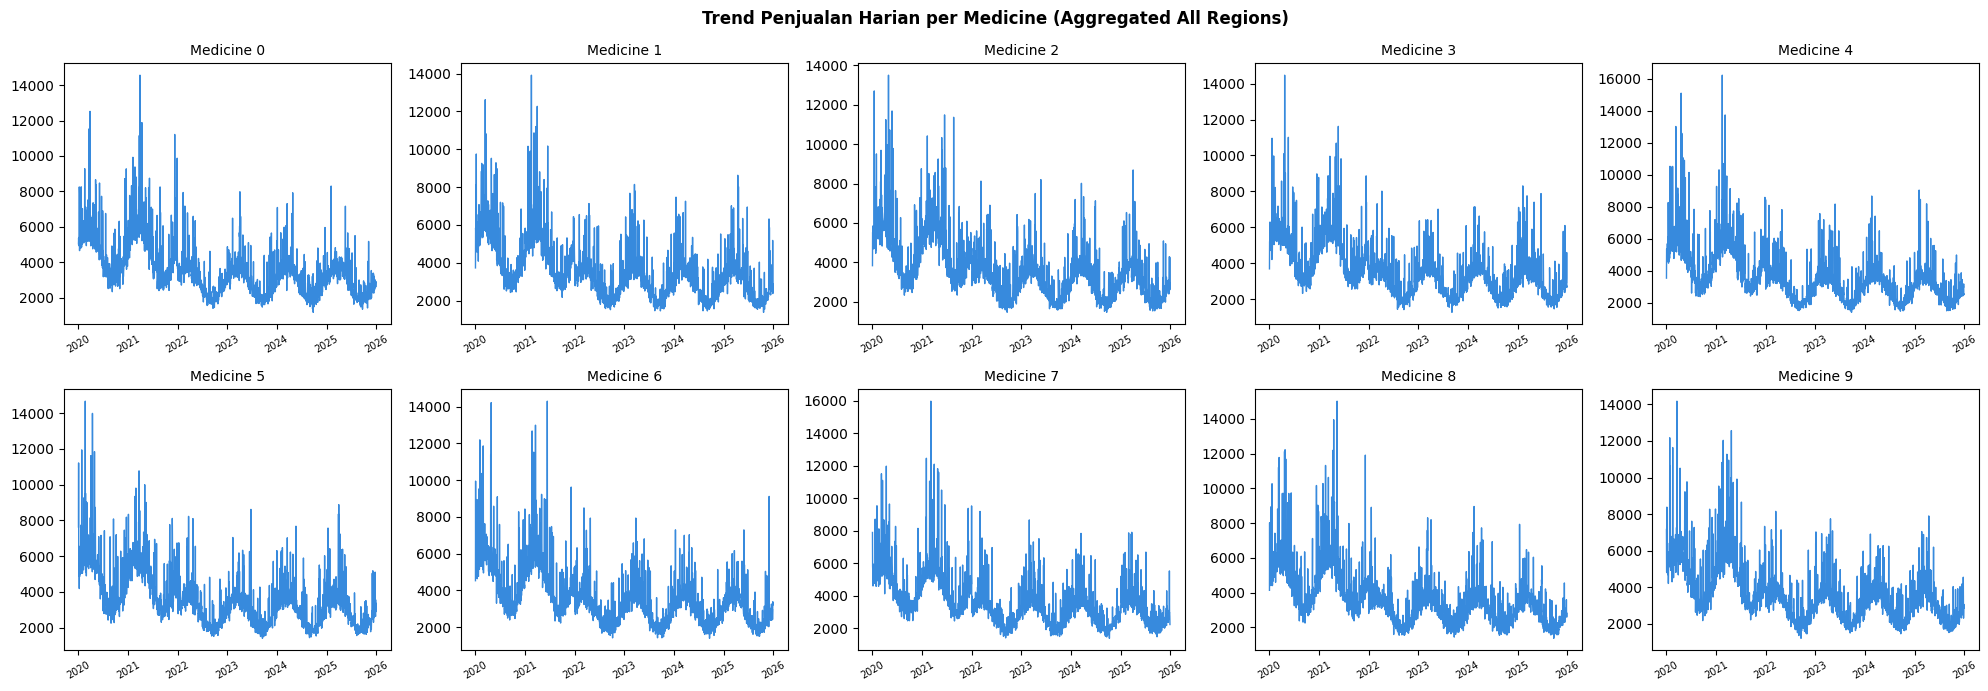

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=False)
axes = axes.flatten()

df_sorted = df_raw.sort_values(['medicine', 'date'])

for idx, med_id in enumerate(sorted(df_sorted['medicine'].unique())):
    df_med = df_sorted[df_sorted['medicine'] == med_id]
    # Agregasi harian (sum semua region)
    daily = df_med.groupby('date')['units_sold'].sum().reset_index()
    axes[idx].plot(daily['date'], daily['units_sold'], linewidth=1, color='#378ADD')
    axes[idx].set_title(f'Medicine {med_id}', fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', labelsize=7, rotation=30)

fig.suptitle('Trend Penjualan Harian per Medicine (Aggregated All Regions)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Outlier Detection & Winsorizing — Train-Only per Medicine


In [ ]:
def winsorize_train_only(df, col='units_sold', train_ratio=0.8, upper_pct=0.99):
    """
    Cap nilai kolom berdasarkan persentil dari train portion SAJA per medicine.
    Batas ditentukan dari data historis (train), bukan dari seluruh dataset.

    Parameters
    ----------
    df          : DataFrame — sudah di-sort ['medicine', 'date']
    col         : str       — kolom target
    train_ratio : float     — proporsi train (0.8 = 80% awal sebagai train)
    upper_pct   : float     — persentil atas untuk cap (0.99 = P99)
    """
    df = df.copy().sort_values(['medicine', 'date']).reset_index(drop=True)
    log = []

    for med in sorted(df['medicine'].unique()):
        mask   = df['medicine'] == med
        df_med = df.loc[mask].copy()

        # Tentukan batas train
        split  = int(train_ratio * len(df_med))
        train_series = df_med[col].iloc[:split]

        # Hitung cap dari train SAJA
        cap_upper = train_series.quantile(upper_pct)
        cap_lower = train_series.quantile(1 - upper_pct)

        n_clipped = ((df_med[col] > cap_upper) | (df_med[col] < cap_lower)).sum()

        # Terapkan ke seluruh medicine (train + test) menggunakan batas train
        df.loc[mask, col] = df.loc[mask, col].clip(lower=cap_lower, upper=cap_upper)

        if n_clipped > 0:
            log.append({'medicine': med, 'n_clipped': n_clipped,
                        'cap_lower': round(cap_lower, 1), 'cap_upper': round(cap_upper, 1)})

    return df, log


df = df_raw.copy().sort_values(['medicine', 'date']).reset_index(drop=True)
df, winsor_log = winsorize_train_only(df, col='units_sold')

print("=" * 55)
print("  HASIL WINSORIZING (Train-Only per Medicine)")
print("=" * 55)
print(f"  Medicine diproses     : {df['medicine'].nunique()}")
print(f"  Medicine ada clipping : {len(winsor_log)}")
print()

if winsor_log:
    print(pd.DataFrame(winsor_log).to_string(index=False))
    print()

print("Distribusi units_sold setelah winsorizing:")
print(df['units_sold'].describe().round(2))


  HASIL WINSORIZING (Train-Only per Medicine)
  Medicine diproses     : 10
  Medicine ada clipping : 10

 medicine  n_clipped  cap_lower  cap_upper
        0        357      134.0     1595.2
        1        388      137.0     1404.7
        2        355      138.0     1759.1
        3        376      137.0     1510.4
        4        360      137.0     1572.4
        5        349      135.0     1657.4
        6        366      139.0     1858.4
        7        353      134.0     1720.4
        8        343      133.0     1858.7
        9        366      138.0     1738.4

Distribusi units_sold setelah winsorizing:
count    175340.00
mean        435.09
std         228.21
min         133.00
25%         284.00
50%         387.00
75%         528.00
max        1858.70
Name: units_sold, dtype: float64


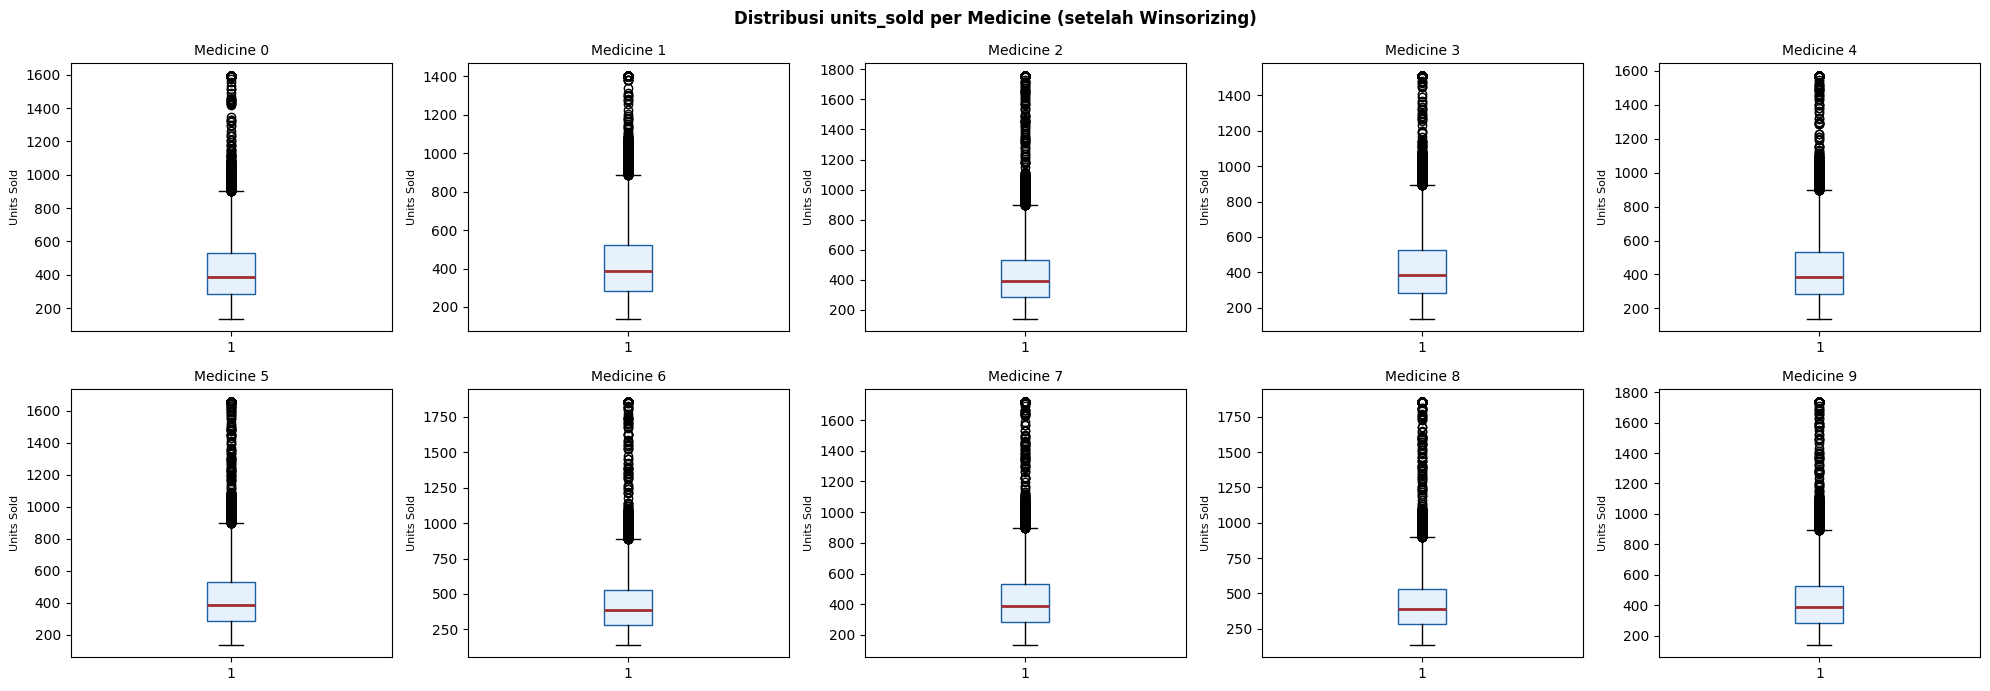

In [ ]:
# Visualisasi boxplot setelah winsorizing — per medicine
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for idx, med_id in enumerate(sorted(df['medicine'].unique())):
    df_med = df[df['medicine'] == med_id]
    axes[idx].boxplot(df_med['units_sold'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#E6F1FB', color='#185FA5'),
                      medianprops=dict(color='#A32D2D', linewidth=2))
    axes[idx].set_title(f'Medicine {med_id}', fontsize=10)
    axes[idx].set_ylabel('Units Sold', fontsize=8)

fig.suptitle('Distribusi units_sold per Medicine (setelah Winsorizing)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Correlation Analysis & Feature Selection — Train-Only




In [ ]:
# Kumpulkan hanya train rows (80% awal per medicine)
train_rows = []
for med in sorted(df['medicine'].unique()):
    df_med = df[df['medicine'] == med].sort_values('date')
    split  = int(0.8 * len(df_med))
    train_rows.append(df_med.iloc[:split])

df_train_only = pd.concat(train_rows, ignore_index=True)

print(f"Baris train-only untuk korelasi: {len(df_train_only):,} "
      f"({len(df_train_only)/len(df)*100:.1f}% dari total)")
print()

# Kolom kandidat korelasi (hanya numerik, kecuali ID dan kalender murni)
exclude_from_corr = ['year', 'month', 'region', 'country', 'age_group', 'quarter']
corr_candidates   = [c for c in df_train_only.select_dtypes(include='number').columns
                     if c not in exclude_from_corr + ['medicine']]

corr_matrix = df_train_only[corr_candidates].corr()

# Korelasi terhadap target
sales_corr = (corr_matrix['units_sold']
              .drop('units_sold')
              .abs()
              .sort_values(ascending=False))

print("=== KORELASI TERHADAP units_sold (dari train-only) ===")
print(sales_corr.round(4).to_string())


Baris train-only untuk korelasi: 140,270 (80.0% dari total)

=== KORELASI TERHADAP units_sold (dari train-only) ===
stock_level              0.8469
stock_coverage_days      0.5754
avg_sales_2              0.3794
rolling_mean_2           0.3794
lag_2                    0.2955
lag_1                    0.2941
growth_rate              0.0041
unit_price               0.0030
expiry_days_remaining    0.0021
category                 0.0013
price_change             0.0008
near_expiry              0.0004


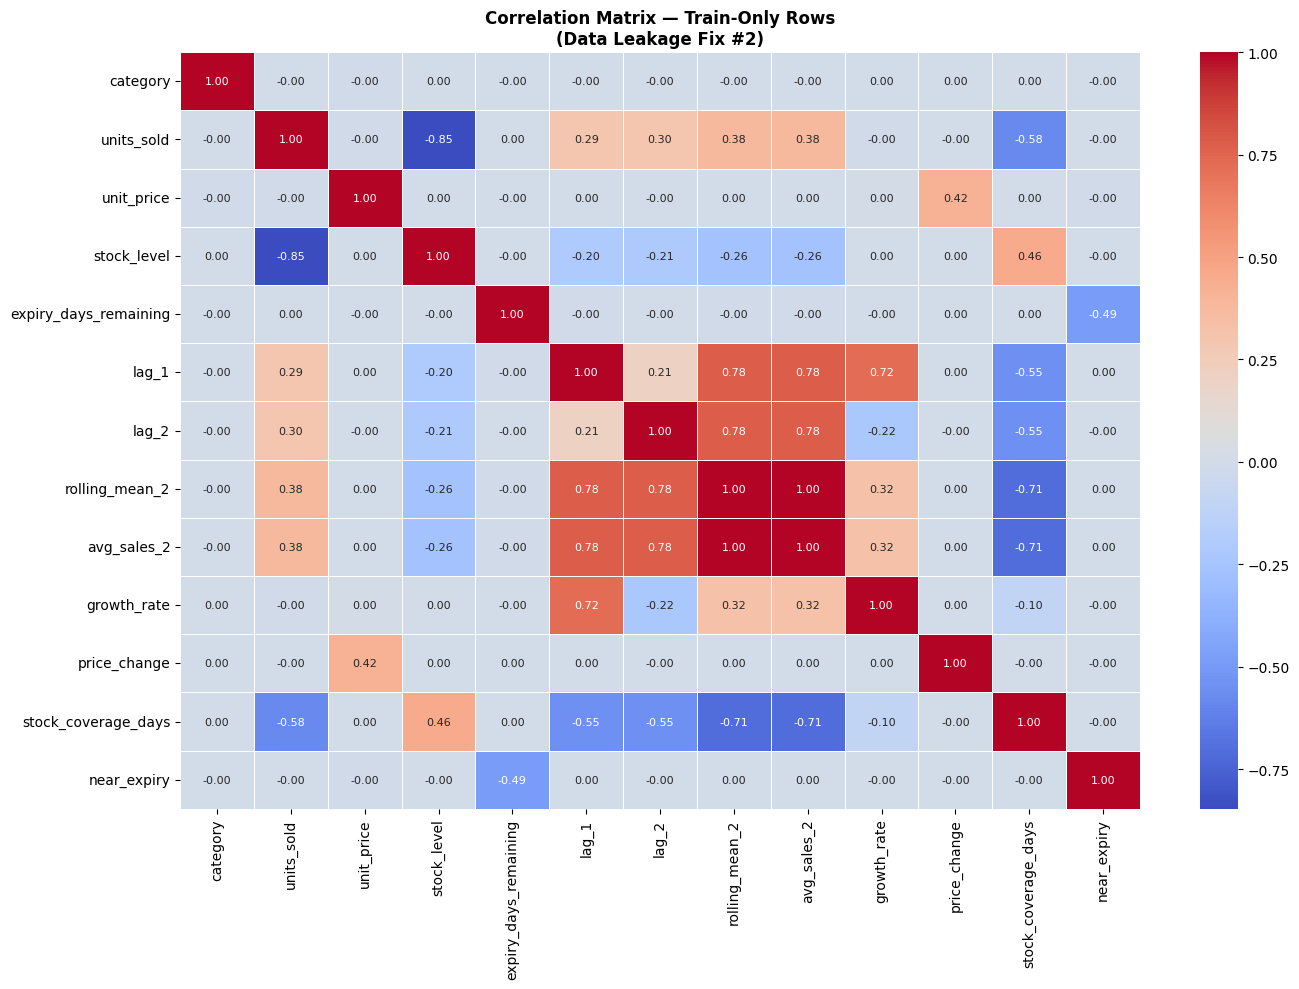

In [ ]:
# Heatmap korelasi (dari train-only)
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True, cmap='coolwarm', fmt='.2f',
    annot_kws={'size': 8}, linewidths=0.5
)
plt.title('Correlation Matrix — Train-Only Rows\n(Data Leakage Fix #2)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# PEMILIHAN FITUR DATASET BARU
# ============================================================
# Berdasarkan korelasi train-only + relevansi domain farmasi:
#
# DIPILIH:
#   units_sold          → target sekaligus fitur autoregresif (t-1)
#   stock_level         → stok saat ini, sangat penting untuk ROP
#   lag_1               → penjualan kemarin (korelasi tinggi)
#   lag_2               → penjualan 2 hari lalu
#   rolling_mean_2      → moving average 2 hari
#   growth_rate         → tren pertumbuhan permintaan
#   stock_coverage_days → hari ketahanan stok (menggantikan 'coverage')
#   expiry_days_remaining → sisa hari kadaluarsa (lebih informatif dari near_expiry biner)
#   near_expiry         → flag kadaluarsa (berguna untuk klasifikasi service level)
#
# TIDAK DIPILIH:
#   lag_3, rolling_mean_3 → tidak ada di dataset baru (ada lag_2, rolling_mean_2)
#   unit_price            → korelasi sangat rendah (~0)
#   price_change          → noise tinggi, korelasi rendah
#   avg_sales_2           → identik dengan rolling_mean_2 (redundan)
#   year/month/quarter/region/country/category/age_group → bukan fitur prediktif LSTM
# ============================================================

features   = [
    'units_sold',
    'stock_level',
    'lag_1',
    'lag_2',
    'rolling_mean_2',
    'growth_rate',
    'stock_coverage_days',
    'expiry_days_remaining',
    'near_expiry',
]
target_col = 'units_sold'
target_idx = features.index(target_col)   # = 0

print("Fitur yang digunakan untuk LSTM:")
for i, f in enumerate(features):
    marker = ' ← TARGET' if f == target_col else ''
    print(f"  [{i}] {f}{marker}")
print()
print(f"Total fitur : {len(features)}")
print()
# Preview
df[features].head(3)


Fitur yang digunakan untuk LSTM:
  [0] units_sold ← TARGET
  [1] stock_level
  [2] lag_1
  [3] lag_2
  [4] rolling_mean_2
  [5] growth_rate
  [6] stock_coverage_days
  [7] expiry_days_remaining
  [8] near_expiry

Total fitur : 9



,units_sold,stock_level,lag_1,lag_2,rolling_mean_2,growth_rate,stock_coverage_days,expiry_days_remaining,near_expiry
0,897.0,3989,684.0,672.0,678.0,0.017857,5.874816,104,0
1,967.0,3964,897.0,684.0,790.5,0.311404,5.008212,498,0
2,913.0,3932,967.0,897.0,932.0,0.078038,4.214362,559,0


## 6. Sequence Building — Split 70 / 15 / 15 per Medicine

In [ ]:
# ============================================================
# [REVISI CELL 12] Split 70/15/15 + Scaler fit train-only + Boundary Overlap
# ============================================================

sequence_length = 30

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []
X_test_list,  y_test_list  = [], []
scalers = {}

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.85

skipped = []

def make_sequences(data, seq_len, t_idx):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, t_idx])
    return X, y

for medicine_id in sorted(df['medicine'].unique()):
    df_med = df[df['medicine'] == medicine_id].sort_values('date').copy()

    if len(df_med) <= sequence_length:
        skipped.append(medicine_id)
        continue

    med_data = df_med[features].values
    n = len(med_data)

    split_train = int(TRAIN_RATIO * n)
    split_val   = int(VAL_RATIO * n)

    # Validasi panjang data
    if (split_val - split_train) <= 0 or (n - split_val) <= 0:
        skipped.append(medicine_id)
        continue

    # [EKSEKUSI FIX] Fit Scaler murni di Train
    train_data_raw = med_data[:split_train]
    scaler = MinMaxScaler()
    scaler.fit(train_data_raw)
    scalers[medicine_id] = scaler

    # Transform seluruh data menggunakan scaler Train
    med_data_scaled = scaler.transform(med_data)

    # [BOUNDARY FIX] Potong data dengan overlap (mundur sejauh sequence_length)
    train_scaled = med_data_scaled[:split_train]
    val_scaled   = med_data_scaled[split_train - sequence_length : split_val]
    test_scaled  = med_data_scaled[split_val - sequence_length :]

    # Buat sequences
    Xtr, ytr = make_sequences(train_scaled, sequence_length, target_idx)
    Xvl, yvl = make_sequences(val_scaled,   sequence_length, target_idx)
    Xts, yts = make_sequences(test_scaled,  sequence_length, target_idx)

    X_train_list.extend(Xtr); y_train_list.extend(ytr)
    X_val_list.extend(Xvl);   y_val_list.extend(yvl)
    X_test_list.extend(Xts);  y_test_list.extend(yts)

X_train = np.array(X_train_list);  y_train = np.array(y_train_list)
X_val   = np.array(X_val_list);    y_val   = np.array(y_val_list)
X_test  = np.array(X_test_list);   y_test  = np.array(y_test_list)

print("=" * 50)
print("  TRAIN / VAL / TEST SHAPE (BOUNDARY FIXED)")
print("=" * 50)
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"  Scalers tersimpan : {len(scalers)} medicine")

  TRAIN / VAL / TEST SHAPE (BOUNDARY FIXED)
  X_train : (122430, 30, 9)  |  y_train : (122430,)
  X_val   : (26300, 30, 9)    |  y_val   : (26300,)
  X_test  : (26310, 30, 9)   |  y_test  : (26310,)
  Scalers tersimpan : 10 medicine


## 7. Build Model LSTM

In [ ]:
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # input_shape = (batch_size, time_steps, lstm_units)
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super().build(input_shape)

    def call(self, x):
        # Menghitung skor atensi untuk setiap langkah waktu (hari)
        e = tf.keras.activations.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        alpha = tf.keras.activations.softmax(e, axis=1)
        # Menghasilkan vektor konteks yang difokuskan pada hari-hari penting
        context_vector = tf.reduce_sum(x * alpha, axis=1)
        return context_vector

# ------------------------------------------------------------
# 2. CUSTOM MODEL & GRADIENT TAPE LOOP (MVP 1 & SQ 2)
# ------------------------------------------------------------
class PharmaSixModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Definisi Lapisan
        self.lstm1 = LSTM(128, return_sequences=True, name="lstm_extractor_1")
        self.drop1 = Dropout(0.15)
        self.lstm2 = LSTM(64, return_sequences=True, name="lstm_extractor_2")
        self.attention = TemporalAttention(name="pharmacy_attention")
        self.dense_hidden = Dense(32, activation='relu')
        self.out_layer = Dense(1, name="forecast_output")

    def call(self, inputs, training=False):
        x = self.lstm1(inputs)
        x = self.drop1(x, training=training)
        x = self.lstm2(x)
        x = self.attention(x) # Masuk ke mekanisme atensi
        x = self.dense_hidden(x)
        return self.out_layer(x)

    # Inilah eksekusi tf.GradientTape yang bersih dan elegan
    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)  # Forward pass
            # Hitung kerugian menggunakan Asymmetric Loss
            loss = self.compiled_loss(y, y_pred, regularization_losses=self.losses)

        # Propagasi Balik (Backward pass)
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Perbarui metrik (MAE)
        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

# ------------------------------------------------------------
# 3. CUSTOM CALLBACK (MVP 2)
# ------------------------------------------------------------
class PharmaCommandMonitor(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_mae = logs.get('val_mae')
        if val_mae and val_mae < 0.04:
            print(f"\n[COMMAND TACTICAL] Epoch {epoch+1} - Val MAE {val_mae:.4f}: Ambang batas keamanan operasional tercapai.")

# ============================================================
# INISIASI & PELATIHAN
# ============================================================

# Bentuk Input
input_shape = (X_train.shape[1], X_train.shape[2])
inputs = Input(shape=input_shape)

# Inisiasi Model Subclass
model = PharmaSixModel()
# Trigger build model dengan dummy input
model(tf.zeros((1, input_shape[0], input_shape[1])))

# Kompilasi
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

# Persiapan Callback Standar & Kustom
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = 'logs/pharma_advanced/' + current_time

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    TensorBoard(log_dir=log_dir, histogram_freq=1), # SQ 4
    PharmaCommandMonitor() # MVP 2
]

print("=" * 60)
print("  🚀 MEMULAI PELATIHAN: PHARMASIX ADVANCED ARCHITECTURE")
print("=" * 60)

# Karena kita melakukan override train_step, kita bisa menggunakan model.fit()
# dengan segala kemudahannya, tetapi proses di baliknya MURNI tf.GradientTape.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

print("\nPelatihan Selesai. Mengekspor Model ke format H5/Keras...")
model.save('pharmasix_v3_lstm_advanced.keras')
print("Model produksi berhasil dibekukan.")

  🚀 MEMULAI PELATIHAN: PHARMASIX ADVANCED ARCHITECTURE
Epoch 1/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 52s 12ms/step - mae: 0.0793 - loss: 0.2184 - val_loss: 0.0121 - val_mae: 0.0645
Epoch 2/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - mae: 0.0776 - loss: 0.2188 - val_loss: 0.0116 - val_mae: 0.0614
Epoch 3/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - mae: 0.0751 - loss: 0.2189 - val_loss: 0.0105 - val_mae: 0.0591
Epoch 4/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - mae: 0.0734 - loss: 0.2189 - val_loss: 0.0101 - val_mae: 0.0576
Epoch 5/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - mae: 0.0726 - loss: 0.2189 - val_loss: 0.0101 - val_mae: 0.0570
Epoch 6/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - mae: 0.0721 - loss: 0.2189 - val_loss: 0.0098 - val_mae: 0.0562
Epoch 7/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - mae: 0.0715 - loss: 0.2188 - val_loss: 0.0098 - val_mae: 0.0564
Epoch 8/150
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - mae: 0.0711 - loss: 0.219

## 8. Prediksi & Inverse Transform — Per Medicine

Inverse transform menggunakan scaler masing-masing medicine (bukan scaler tunggal).
Test set baru disentuh di sini untuk evaluasi akhir.


In [ ]:
# ============================================================
# PREDIKSI PADA TEST SET
# ============================================================

predictions = model.predict(X_test, verbose=0)
print(f"Shape prediksi  : {predictions.shape}")
print(f"Sample 5 pertama (normalized): {predictions[:5].flatten().round(4)}")


Shape prediksi  : (26310, 1)
Sample 5 pertama (normalized): [0.1946 0.1919 0.2361 0.2038 0.1876]


In [ ]:
# ============================================================
# INVERSE TRANSFORM PER MEDICINE
# ============================================================

lstm_forecasts = {}
all_pred, all_actual = [], []
idx = 0

for medicine_id in sorted(df['medicine'].unique()):
    if medicine_id not in scalers or medicine_id in skipped:
        continue

    # Hitung jumlah test set spesifik untuk obat ini
    df_med = df[df['medicine'] == medicine_id].sort_values('date')
    n = len(df_med)
    split_val = int(VAL_RATIO * n)
    n_test = n - split_val # Karena overlap, jumlah sampel test sama dengan n_test

    if n_test <= 0:
        continue

    sc = scalers[medicine_id]

    # Inverse predict untuk obat spesifik ini
    pred_norm = predictions[idx: idx + n_test]
    dummy_p = np.zeros((len(pred_norm), len(features)))
    dummy_p[:, target_idx] = pred_norm.flatten()
    pred_actual = sc.inverse_transform(dummy_p)[:, target_idx]

    # Inverse actual
    act_norm = y_test[idx: idx + n_test]
    dummy_a = np.zeros((len(act_norm), len(features)))
    dummy_a[:, target_idx] = act_norm
    act_actual = sc.inverse_transform(dummy_a)[:, target_idx]

    all_pred.extend(pred_actual)
    all_actual.extend(act_actual)

    # [EKSEKUSI FIX] Simpan nilai AI spesifik per obat!
    lstm_forecasts[medicine_id] = {
        'forecast_last': float(pred_actual[-1]),
        'forecast_std' : float(np.std(pred_actual))
    }

    idx += n_test

predicted_units = np.array(all_pred)
actual_units    = np.array(all_actual)

print(f"Total sampel ter-inverse: {len(predicted_units)}")
print(f"Obat berhasil dipetakan ke dictionary AI: {len(lstm_forecasts)} items")


Total sampel ter-inverse: 26310
Obat berhasil dipetakan ke dictionary AI: 10 items


## 9. Evaluasi Model

In [ ]:
mae  = mean_absolute_error(actual_units, predicted_units)
rmse = np.sqrt(mean_squared_error(actual_units, predicted_units))
mean_actual = actual_units.mean()

print("=" * 50)
print("  MODEL EVALUATION — TEST SET")
print("  (Test set belum pernah disentuh saat training)")
print("=" * 50)
print(f"  MAE        : {mae:.4f} unit")
print(f"  RMSE       : {rmse:.4f} unit")
print(f"  Mean Actual: {mean_actual:.2f} unit")
print(f"  MAE/Mean   : {mae/mean_actual*100:.2f}%  (error relatif)")
print("=" * 50)


  MODEL EVALUATION — TEST SET
  (Test set belum pernah disentuh saat training)
  MAE        : 83.5909 unit
  RMSE       : 143.8807 unit
  Mean Actual: 356.64 unit
  MAE/Mean   : 23.44%  (error relatif)


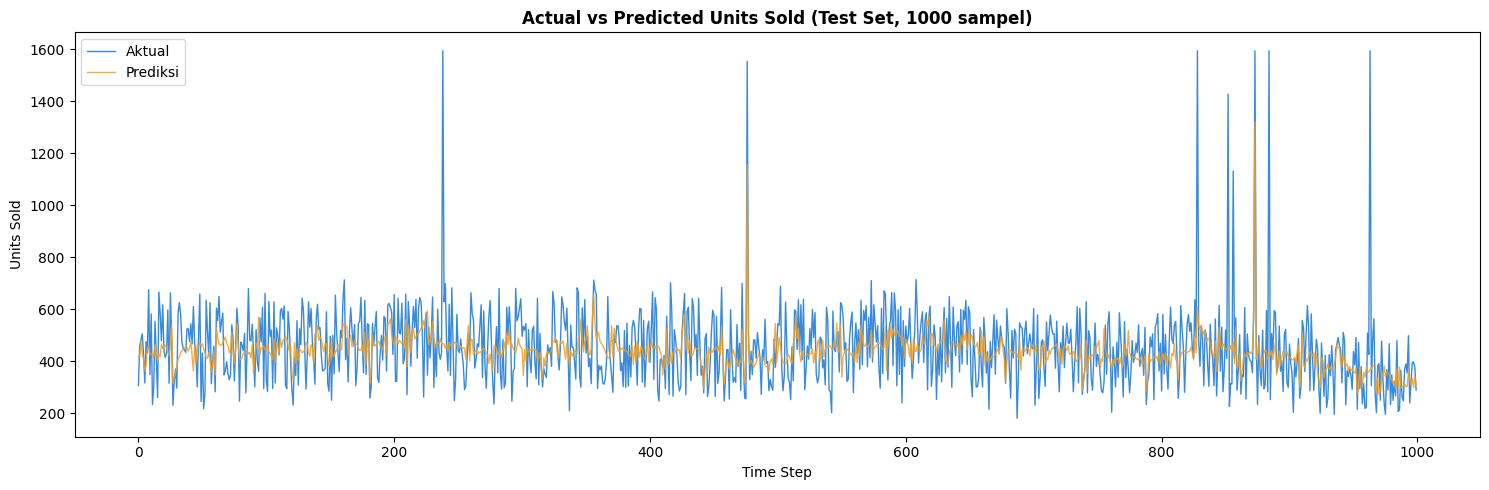

In [ ]:
# Plot Actual vs Predicted (1000 sampel pertama agar terbaca)
n_plot = min(1000, len(actual_units))

plt.figure(figsize=(15, 5))
plt.plot(actual_units[:n_plot],    label='Aktual',   color='#378ADD', linewidth=1)
plt.plot(predicted_units[:n_plot], label='Prediksi', color='#EF9F27', linewidth=1, alpha=0.85)
plt.title(f'Actual vs Predicted Units Sold (Test Set, {n_plot} sampel)',
          fontsize=12, fontweight='bold')
plt.xlabel('Time Step'); plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Simpan Model & Scalers

In [ ]:
model.save('pharmasix_v3_lstm.keras')
joblib.dump(scalers, 'pharmasix_v3_scalers.gz')

print(f"Model disimpan    : pharmasix_v3_lstm.keras")
print(f"Scalers disimpan  : pharmasix_v3_scalers.gz ({len(scalers)} medicine)")
print()
print("Cara load di produksi:")
print("  from tensorflow.keras.models import load_model")
print("  model   = load_model('pharmasix_v3_lstm.keras')")
print("  scalers = joblib.load('pharmasix_v3_scalers.gz')")
print("  sc      = scalers[medicine_id]   # scaler spesifik per obat")


Model disimpan    : pharmasix_v3_lstm.keras
Scalers disimpan  : pharmasix_v3_scalers.gz (10 medicine)

Cara load di produksi:
  from tensorflow.keras.models import load_model
  model   = load_model('pharmasix_v3_lstm.keras')
  scalers = joblib.load('pharmasix_v3_scalers.gz')
  sc      = scalers[medicine_id]   # scaler spesifik per obat


In [ ]:
# Verifikasi load
from tensorflow.keras.models import load_model as _load
MODEL_FILE = 'pharmasix_v3_lstm.keras'

try:
    loaded_model = _load(
        MODEL_FILE,
        custom_objects={
            'TemporalAttention': TemporalAttention,
            'PharmaSixModel': PharmaSixModel
        }
    )
    print(f'✅ Model [{MODEL_FILE}] berhasil dibongkar dan di-load ke memori.')

    # Test Inference Singkat
    sample_pred = loaded_model.predict(X_test[:1], verbose=0)
    print(f'✅ Sample inference berjalan: {sample_pred.flatten()[0]:.6f} (normalized)')

except Exception as e:
    print(f"🚨 FATAL ERROR SAAT LOAD MODEL: {e}")
    print("Pastikan nama file benar dan kelas TemporalAttention & PharmaSixModel sudah dieksekusi di atas.")

✅ Model [pharmasix_v3_lstm.keras] berhasil dibongkar dan di-load ke memori.
✅ Sample inference berjalan: 0.194594 (normalized)


In [ ]:
%%writefile model_api.py

import os
import numpy as np
import pandas as pd
import joblib
from fastapi import FastAPI, HTTPException
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Layer
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from scipy import stats as scipy_stats
from typing import List, Dict, Union

# --- Custom Keras Layers (MUST be defined for model loading) ---
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.activations.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        alpha = tf.keras.activations.softmax(e, axis=1)
        context_vector = tf.reduce_sum(x * alpha, axis=1)
        return context_vector

class PharmaSixModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.lstm1 = LSTM(128, return_sequences=True, name="lstm_extractor_1")
        self.drop1 = Dropout(0.15)
        self.lstm2 = LSTM(64, return_sequences=True, name="lstm_extractor_2")
        self.attention = TemporalAttention(name="pharmacy_attention")
        self.dense_hidden = Dense(32, activation='relu')
        self.out_layer = Dense(1, name="forecast_output")

    def call(self, inputs, training=False):
        x = self.lstm1(inputs)
        x = self.drop1(x, training=training)
        x = self.lstm2(x)
        x = self.attention(x)
        x = self.dense_hidden(x)
        return self.out_layer(x)

    # train_step is not needed for inference, but included for completeness if training were part of the API
    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compiled_loss(y, y_pred, regularization_losses=self.losses)

        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}


app = FastAPI()

# --- Global Variables & Model Loading ---
# Define file paths
DATA_FILE_PATH = '/content/data_feature_engineering.csv'
MODEL_FILE = '/content/pharmasix_v3_lstm.keras'
SCALERS_FILE = '/content/pharmasix_v3_scalers.gz'

# Load dataset, model, and scalers once at startup
try:
    df_raw = pd.read_csv(DATA_FILE_PATH)
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    print(f"[API Startup] Successfully loaded {DATA_FILE_PATH}")
except Exception as e:
    print(f"[API Startup Error] Failed to load data_feature_engineering.csv: {e}")
    df_raw = None

try:
    model = load_model(
        MODEL_FILE,
        custom_objects={'TemporalAttention': TemporalAttention, 'PharmaSixModel': PharmaSixModel}
    )
    print(f"[API Startup] Successfully loaded {MODEL_FILE}")
except Exception as e:
    print(f"[API Startup Error] Failed to load model {MODEL_FILE}: {e}")
    model = None

try:
    scalers = joblib.load(SCALERS_FILE)
    print(f"[API Startup] Successfully loaded {SCALERS_FILE}")
except Exception as e:
    print(f"[API Startup Error] Failed to load scalers {SCALERS_FILE}: {e}")
    scalers = None

# --- Feature and Sequence Definitions (as used in training) ---
features = [
    'units_sold',
    'stock_level',
    'lag_1',
    'lag_2',
    'rolling_mean_2',
    'growth_rate',
    'stock_coverage_days',
    'expiry_days_remaining',
    'near_expiry',
]
target_col = 'units_sold'
target_idx = features.index(target_col)
sequence_length = 30

# --- Supply Chain Constants (as used in notebook) ---
SERVICE_LEVELS = {
    'kritis' : 0.99,
    'reguler': 0.95,
    'rendah' : 0.90,
}
z_scores = {k: scipy_stats.norm.ppf(v) for k, v in SERVICE_LEVELS.items()}
LEAD_TIME_MEAN  = 3
LEAD_TIME_STD   = 1

# --- Helper Functions (from notebook) ---
def klasifikasi_service_level(row: dict) -> str:
    if row.get('near_expiry', 0) == 1:
        return 'rendah'
    if row.get('stock_coverage_days', 99) < 3:
        return 'kritis'
    if row.get('expiry_days_remaining', 999) < 60:
        return 'kritis'
    return 'reguler'

def hitung_safety_stock_lstm(forecast_demand: float, forecast_std: float, service_level_key: str = 'reguler') -> dict:
    z = z_scores.get(service_level_key, z_scores['reguler'])
    safety_stock = z * np.sqrt(
        LEAD_TIME_MEAN * (forecast_std ** 2) +
        (forecast_demand ** 2) * (LEAD_TIME_STD ** 2)
    )
    rop = (forecast_demand * LEAD_TIME_MEAN) + safety_stock

    return {
        'lstm_forecast_demand' : round(float(forecast_demand), 2),
        'lstm_forecast_std'    : round(float(forecast_std), 2),
        'safety_stock'         : round(float(safety_stock), 0),
        'reorder_point'        : round(float(rop), 0),
    }

# --- Prediction Function for API ---
def predict_and_calculate_report_for_medicine(medicine_id: int) -> Dict[str, Union[int, float, str]]:
    if df_raw is None or model is None or scalers is None:
        raise HTTPException(status_code=500, detail="API backend not initialized. Model or data not loaded.")

    df_med = df_raw[df_raw['medicine'] == medicine_id].sort_values('date').copy()

    if len(df_med) < sequence_length:
        raise HTTPException(status_code=404, detail=f"Not enough historical data ({len(df_med)} rows) for medicine {medicine_id} to form a sequence of length {sequence_length}.")

    if medicine_id not in scalers:
        raise HTTPException(status_code=404, detail=f"Scaler not found for medicine {medicine_id}.")

    scaler = scalers[medicine_id]

    # Get the last 'sequence_length' rows for prediction
    last_sequence_raw = df_med[features].tail(sequence_length).values
    last_sequence_scaled = scaler.transform(last_sequence_raw)

    # Reshape for LSTM input: (1, sequence_length, num_features)
    X_pred = np.array([last_sequence_scaled])

    # Make prediction
    predicted_scaled = model.predict(X_pred, verbose=0)[0][0]

    # Inverse transform prediction
    dummy_pred = np.zeros((1, len(features)))
    dummy_pred[:, target_idx] = predicted_scaled
    predicted_actual = scaler.inverse_transform(dummy_pred)[:, target_idx][0]
    predicted_actual = max(0.0, predicted_actual) # Ensure non-negative

    # For forecast_std, use standard deviation of units_sold in the last sequence
    # This is a proxy for demand variability. A more sophisticated model would provide this directly.
    forecast_std = np.std(df_med['units_sold'].tail(sequence_length))
    if np.isnan(forecast_std): # Handle cases with constant demand or very few data points
        forecast_std = 0.0

    # Get last known stock information
    last_row = df_med.iloc[-1]
    stok_sekarang = int(last_row['stock_level'])

    # Determine Service Level
    sl_key = klasifikasi_service_level(last_row.to_dict())

    # Calculate Safety Stock and Reorder Point
    supply_chain_data = hitung_safety_stock_lstm(predicted_actual, forecast_std, sl_key)

    rop = supply_chain_data['reorder_point']
    ss = supply_chain_data['safety_stock']

    # Determine Alert Status
    if stok_sekarang <= 0:          alert = 'STOCKOUT'
    elif stok_sekarang < ss:        alert = 'KRITIS'
    elif stok_sekarang < rop:       alert = 'PERLU ORDER'
    else:                           alert = 'AMAN'

    # Calculate Order Recommendation
    order_qty = 0
    if alert in ['STOCKOUT', 'KRITIS', 'PERLU ORDER']:
        order_qty = (predicted_actual * 30) + ss - stok_sekarang # Cover 30 days + Safety Stock
        order_qty = max(0, int(order_qty))

    report = {
        'medicine': medicine_id,
        'service_level': sl_key,
        'status_alert': alert,
        'stock_sekarang': stok_sekarang,
        'stock_coverage_days': round(float(np.nan_to_num(last_row['stock_coverage_days'])), 1),
        'expiry_days_remaining': int(np.nan_to_num(last_row['expiry_days_remaining'])),
        'near_expiry': int(np.nan_to_num(last_row['near_expiry'])),
        'lstm_forecast_demand': supply_chain_data['lstm_forecast_demand'],
        'lstm_forecast_std': supply_chain_data['lstm_forecast_std'],
        'safety_stock': supply_chain_data['safety_stock'],
        'reorder_point': supply_chain_data['reorder_point'],
        'order_rekomendasi': order_qty,
    }
    return report

# --- API Endpoints ---
@app.get("/check-all", response_model=List[Dict[str, Union[int, float, str]]])
async def get_all_medicine_reports():
    if df_raw is None:
        raise HTTPException(status_code=500, detail="Data not loaded, cannot generate report.")

    all_medicine_reports = []
    unique_medicines = sorted(df_raw['medicine'].unique())

    for med_id in unique_medicines:
        try:
            report = predict_and_calculate_report_for_medicine(int(med_id))
            all_medicine_reports.append(report)
        except HTTPException as e:
            print(f"Warning: Skipped medicine {med_id} due to error: {e.detail}")
        except Exception as e:
            print(f"Error processing medicine {med_id}: {e}")

    return all_medicine_reports

@app.get("/report/{medicine_id}", response_model=Dict[str, Union[int, float, str]])
async def get_medicine_report(medicine_id: int):
    try:
        report = predict_and_calculate_report_for_medicine(medicine_id)
        return report
    except HTTPException as e:
        raise e
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"An unexpected error occurred: {e}")

@app.get("/")
async def read_root():
    return {"message": "PharmaSix v3 Forecasting API. Use /check-all or /report/{medicine_id} for reports."}

Writing model_api.py


In [ ]:
# Update paths in model_api.py to be relative for Railway deployment
'''import re

with open('model_api.py', 'r') as f:
    content = f.read()

# Replace absolute paths with relative paths
content = re.sub(r"DATA_FILE_PATH = '/content/(.*?)'", r"DATA_FILE_PATH = './\1'", content)
content = re.sub(r"MODEL_FILE = '/content/(.*?)'", r"MODEL_FILE = './\1'", content)
content = re.sub(r"SCALERS_FILE = '/content/(.*?)'", r"SCALERS_FILE = './\1'", content)

with open('model_api.py', 'w') as f:
    f.write(content)

print("model_api.py updated to use relative paths for Railway deployment.")'''

model_api.py updated to use relative paths for Railway deployment.


The `model_api.py` file has been created. Now, you need to run the Uvicorn server to make the API accessible. Execute the following command in a new cell. **Keep this cell running to keep your API active.**

### Accessing API tanpa ngrok, lewat cmd

    1. buka folder C:\Users\MyBook Army\Downloads\farma, terus run cmd
    2. di cmd venv\Scripts\activate
    3. uvicorn model_api:app --host 127.0.0.1 --port 8000
    4. buka di browser http://127.0.0.1:8000/docs


In [ ]:
#!ngrok authtoken 3EAqMOevgJxov3uUORkS3uY0k3G_44313vsJhSnL5Mz867kaN

In [ ]:
!kill -9 $(lsof -t -i:8000)

kill: usage: kill [-s sigspec | -n signum | -sigspec] pid | jobspec ... or kill -l [sigspec]


In [ ]:
#!uvicorn model_api:app --host 0.0.0.0 --port 8000 &

In [ ]:
'''from pyngrok import ngrok

public_url = ngrok.connect(8000)
print(public_url)'''

'from pyngrok import ngrok\n\npublic_url = ngrok.connect(8000)\nprint(public_url)'

In [ ]:
import os
import time
import socket
import subprocess

def is_port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        try:
            s.bind(("127.0.0.1", port))
            return False # Bind successful, port is free
        except OSError:
            return True # Bind failed, port is in use

# --- Aggressive Port Cleanup ---
print(f"Attempting aggressive port cleanup for port {API_PORT}...") # Fixed f-string
# Use 'lsof' to find processes using the port and kill them
try:
    # Find PID using the port
    result = subprocess.run(['lsof', '-i', f':{API_PORT}', '-t'], capture_output=True, text=True)
    pids = result.stdout.strip().split('\n')
    pids = [p for p in pids if p]

    for pid in pids:
        print(f"  Found process {pid} using port {API_PORT}. Attempting to kill...")
        try:
            os.kill(int(pid), 9) # Kill forcefully
            time.sleep(1) # Give it a moment
        except ProcessLookupError:
            print(f"  Process {pid} already gone.")
        except Exception as e:
            print(f"  Error killing process {pid}: {e}")
except FileNotFoundError:
    print("  lsof command not found. Falling back to fuser.")
    os.system(f"fuser -k {API_PORT}/tcp >/dev/null 2>&1 || true")

# Fallback/additional fuser cleanup
os.system(f"fuser -k {API_PORT}/tcp >/dev/null 2>&1 || true")
time.sleep(3) # Give more time for the port to be released

# Robustly wait until the port is truly free for binding
max_retries = 10
retry_delay = 2 # seconds
for i in range(max_retries):
    if not is_port_in_use(API_PORT):
        print(f"Port {API_PORT} is free after {i+1} attempts.")
        break
    else:
        print(f"Port {API_PORT} still in use. Retrying in {retry_delay} seconds...")
        os.system(f"fuser -k {API_PORT}/tcp >/dev/null 2>&1 || true") # Try fuser again
        time.sleep(retry_delay)
else:
    print(f"Error: Port {API_PORT} remains in use after multiple attempts. This might cause Uvicorn to fail.")

# Clear uvicorn.log before starting to get fresh logs
uvicorn_log_file = 'uvicorn.log'
if os.path.exists(uvicorn_log_file):
    os.remove(uvicorn_log_file)

# Remove old PID file if it exists
pid_file = 'uvicorn.pid'
if os.path.exists(pid_file):
    os.remove(pid_file)

# Run uvicorn in the background using nohup and save PID to file
print("Starting Uvicorn server in the background...")
# Removed --reload flag to avoid potential port binding issues during restarts
# Capture stderr to log file as well for better debugging
os.system(f'nohup uvicorn model_api:app --host {API_HOST} --port {API_PORT} > {uvicorn_log_file} 2>&1 & echo $! > {pid_file}')

# Give the server a moment to start up, and then check log for success
server_started = False
startup_timeout = 30 # seconds
check_interval = 2 # seconds
uvicorn_error_found = False # New variable to track specific errors

for _ in range(startup_timeout // check_interval):
    if os.path.exists(uvicorn_log_file):
        with open(uvicorn_log_file, 'r') as f:
            log_content = f.read()

            # Prioritize error detection
            if "ERROR: [Errno 98] Address already in use" in log_content or "Failed to bind" in log_content:
                print("Uvicorn server failed to start (binding error detected in log).")
                uvicorn_error_found = True
                server_started = False
                break # Exit loop as error found

            # If no error, check for successful startup message
            if "Application startup complete." in log_content:
                server_started = True
                break # Exit loop as success found

    time.sleep(check_interval)

if server_started:
    print("Uvicorn server started successfully (verified via log).")
    print(f"API accessible at http://127.0.0.1:{API_PORT}")
elif uvicorn_error_found:
    print("Uvicorn server failed to start due to a binding error. Please check the log for details.")
else:
    print("Uvicorn server failed to start within the expected time or an error occurred. Check uvicorn.log for details.")

print(f"To stop the server, you can run: `!kill $(cat {pid_file})`")

Attempting aggressive port cleanup for port 8000...
Port 8000 is free after 1 attempts.
Starting Uvicorn server in the background...
Uvicorn server started successfully (verified via log).
API accessible at http://127.0.0.1:8000
To stop the server, you can run: `!kill $(cat uvicorn.pid)`


Once the Uvicorn server is running, you can test the API. I'll add a cell to check the `/check-all` endpoint.

In [ ]:
import requests

# Assuming the FastAPI app is running on 0.0.0.0:8000 within the Colab VM
api_url = f"http://127.0.0.1:{API_PORT}/check-all"

try:
    response = requests.get(api_url)
    response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
    print("API Connection successful!")
    print("Response Status Code:", response.status_code)
    # Pretty print JSON response
    import json
    print("Response JSON:", json.dumps(response.json(), indent=2))
except requests.exceptions.RequestException as e:
    print(f"API Connection failed: {e}")
    print("Please ensure the Uvicorn server is running correctly in the previous cell and try again.")

API Connection successful!
Response Status Code: 200
Response JSON: [
  {
    "medicine": 0,
    "service_level": "reguler",
    "status_alert": "AMAN",
    "stock_sekarang": 4396,
    "stock_coverage_days": 13.7,
    "expiry_days_remaining": 140,
    "near_expiry": 0,
    "lstm_forecast_demand": 339.56,
    "lstm_forecast_std": 83.75,
    "safety_stock": 607.0,
    "reorder_point": 1626.0,
    "order_rekomendasi": 0
  },
  {
    "medicine": 1,
    "service_level": "reguler",
    "status_alert": "AMAN",
    "stock_sekarang": 4611,
    "stock_coverage_days": 12.7,
    "expiry_days_remaining": 124,
    "near_expiry": 0,
    "lstm_forecast_demand": 309.5,
    "lstm_forecast_std": 485.82,
    "safety_stock": 1475.0,
    "reorder_point": 2403.0,
    "order_rekomendasi": 0
  },
  {
    "medicine": 2,
    "service_level": "reguler",
    "status_alert": "AMAN",
    "stock_sekarang": 4406,
    "stock_coverage_days": 11.2,
    "expiry_days_remaining": 699,
    "near_expiry": 0,
    "lstm_forecas

In [ ]:
print('--- Uvicorn Log ---')
with open('uvicorn.log', 'r') as f:
    print(f.read())
print('-------------------')

--- Uvicorn Log ---
2026-05-27 06:20:07.737810: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779862807.739412   12655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13357 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
INFO:     Started server process [12655]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
[API Startup] Successfully loaded ./data_feature_engineering.csv
[API Startup] Successfully loaded ./pharmasix_v3_lstm.keras
[API Startup] Successfully loaded ./pharmasix_v3_scalers.gz
INFO:     127.0.0.1:54648 - "GET /check-all HTTP/1.1" 200 OK

-------------------


In [ ]:
print('--- Uvicorn Log ---')
with open('uvicorn.log', 'r') as f:
    print(f.read())
print('-------------------')

# Re-saving model and scalers
# This cell was ShbikLKZDsif earlier, re-executing for robustness
import joblib
model.save('pharmasix_v3_lstm.keras')
joblib.dump(scalers, 'pharmasix_v3_scalers.gz')

print(f"Model re-saved    : pharmasix_v3_lstm.keras")
print(f"Scalers re-saved  : pharmasix_v3_scalers.gz ({len(scalers)} medicine)")

--- Uvicorn Log ---
2026-05-27 06:20:07.737810: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779862807.739412   12655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13357 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
INFO:     Started server process [12655]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
[API Startup] Successfully loaded ./data_feature_engineering.csv
[API Startup] Successfully loaded ./pharmasix_v3_lstm.keras
[API Startup] Successfully loaded ./pharmasix_v3_scalers.gz
INFO:     127.0.0.1:54648 - "GET /check-all HTTP/1.1" 200 OK

-------------------
Model re-saved    : pharmasix_v3_lstm.keras
Scalers re-saved  : pharmasix_v3_sca

---
## 11. Modul Supply Chain: Safety Stock Berbasis Service Level

---
## Resources

*   **FastAPI Application:** `model_api.py` contains the FastAPI application for connecting the model and backend.
*   **API Endpoints:**
    *   `/`: Returns a welcome message.
    *   `/check-all`: Returns a list of reports for all medicines.
    *   `/report/{medicine_id}`: Returns a report for a specific medicine ID.
*   **Model File:** `pharmasix_v3_lstm.keras`
*   **Scalers File:** `pharmasix_v3_scalers.gz`

## 14. Prepare for Railway Deployment

To deploy this FastAPI application to Railway, we need to create a `requirements.txt` file for all Python dependencies and a `Dockerfile` to define the environment and how to run the application.

**Important:** Ensure that `data_feature_engineering.csv`, `pharmasix_v3_lstm.keras`, and `pharmasix_v3_scalers.gz` are placed in the same directory as your `model_api.py` when you push your code to your Git repository for Railway deployment.

In [ ]:
%%writefile requirements.txt

numpy==1.25.2
pandas==2.0.3
matplotlib==3.7.1
seaboard==0.12.2
scikit-learn==1.2.2
joblib==1.3.2
tensorflow==2.15.0
keras==2.15.0
fastapi==0.104.1
uvicorn==0.23.2
python-multipart==0.0.6
scipy==1.11.4
requests==2.31.0 # If you plan to keep the API testing code
google-generativeai==0.3.0 # If you include chatbot functionality


Overwriting requirements.txt


In [ ]:
%%writefile Dockerfile

# Use an official Python runtime as a parent image
FROM python:3.10-slim

# Set the working directory in the container
WORKDIR /app

# Copy the current directory contents into the container at /app
COPY . /app

# Install any needed packages specified in requirements.txt
RUN pip install --no-cache-dir -r requirements.txt

# Make port 8000 available to the world outside this container
EXPOSE 8000

# Run the uvicorn server with FastAPI
CMD ["uvicorn", "model_api:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting Dockerfile


In [ ]:
%%writefile railway.json
{
  "build": {
    "builder": "NIXPACKS"
  },
  "deploy": {
    "startCommand": "uvicorn model_api:app --host 0.0.0.0 --port 8000",
    "healthcheckPath": "/",
    "healthcheckTimeout": 300
  }
}

Overwriting railway.json


### Deployment Steps for Railway:

1.  **Save all necessary files:** Make sure `model_api.py`, `requirements.txt`, `Dockerfile`, `railway.json`, `data_feature_engineering.csv`, `pharmasix_v3_lstm.keras`, and `pharmasix_v3_scalers.gz` are all in the same directory.
2.  **Initialize a Git repository:**
    ```bash
    git init
    git add .
    git commit -m "Initial commit for PharmaSix API"
    ```
3.  **Create a new project on Railway:**
    *   Go to [Railway.app](https://railway.app/) and log in.
    *   Click on "New Project" -> "Deploy from Git Repo".
    *   Connect your Git provider (GitHub, GitLab, etc.) and select the repository where you pushed your files.
4.  **Configure Railway:**
    *   Railway should automatically detect the `Dockerfile` and `requirements.txt`.
    *   If prompted, ensure the `startCommand` is `uvicorn model_api:app --host 0.0.0.0 --port 8000`.
    *   You might need to set an environment variable for `GOOGLE_API_KEY` if your chatbot functionality is part of the API and requires it. (Though, for this specific API, the chatbot is separate.)
5.  **Deploy:** Click "Deploy" and Railway will build and deploy your application. You can monitor the build logs.
6.  **Access your API:** Once deployed, Railway will provide you with a public URL where your FastAPI application is accessible.

## 12. Chatbot Integration with Gemini API

To integrate a chatbot, we'll use the Gemini API. First, ensure you have your API key stored in Colab's secrets manager (named `GOOGLE_API_KEY`).

In [ ]:
import google.generativeai as genai
from google.colab import userdata

# Retrieve API key from Colab secrets
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

print("Gemini API configured.")

Gemini API configured.


In [ ]:
print("Listing available Gemini models...")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(f"  Model: {m.name}")

Listing available Gemini models...
  Model: models/gemini-2.5-flash
  Model: models/gemini-2.5-pro
  Model: models/gemini-2.0-flash
  Model: models/gemini-2.0-flash-001
  Model: models/gemini-2.0-flash-lite-001
  Model: models/gemini-2.0-flash-lite
  Model: models/gemini-2.5-flash-preview-tts
  Model: models/gemini-2.5-pro-preview-tts
  Model: models/gemma-4-26b-a4b-it
  Model: models/gemma-4-31b-it
  Model: models/gemini-flash-latest
  Model: models/gemini-flash-lite-latest
  Model: models/gemini-pro-latest
  Model: models/gemini-2.5-flash-lite
  Model: models/gemini-2.5-flash-image
  Model: models/gemini-3-pro-preview
  Model: models/gemini-3-flash-preview
  Model: models/gemini-3.1-pro-preview
  Model: models/gemini-3.1-pro-preview-customtools
  Model: models/gemini-3.1-flash-lite-preview
  Model: models/gemini-3.1-flash-lite
  Model: models/gemini-3-pro-image-preview
  Model: models/nano-banana-pro-preview
  Model: models/gemini-3.1-flash-image-preview
  Model: models/gemini-3.5-fl

Now, let's initialize the Gemini model. We'll use a generative model suitable for chat interactions.

In [ ]:
import google.generativeai as genai

try:
    chat_model = genai.GenerativeModel('gemini-2.5-flash')
    print("Gemini 2.5 Flash model initialized for chatbot.")
except Exception as e:
    print(f"Error initializing Gemini model: {e}")
    print("Please ensure the API key is valid and the model is accessible.")

Gemini 2.5 Flash model initialized for chatbot.


Here's a simple function to interact with the chatbot. You can call this function with a prompt to get a response.

In [ ]:
def get_chatbot_response(prompt):
    try:
        if 'chat_model' not in locals() and 'chat_model' not in globals():
            print("Chat model not initialized. Please run the initialization cell.")
            return "Sorry, the chatbot is not available right now."

        response = chat_model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"An error occurred while generating response: {e}"

# Example usage:
user_query = "Hello, what is the best way to manage pharmaceutical inventory?"
chatbot_answer = get_chatbot_response(user_query)
print(f"You: {user_query}")
print(f"Chatbot: {chatbot_answer}")

user_query_2 = "Can you give me a summary of reorder point calculation?"
chatbot_answer_2 = get_chatbot_response(user_query_2)
print(f"\nYou: {user_query_2}")
print(f"Chatbot: {chatbot_answer_2}")

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1666.32ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 10214.07ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2575.67ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1513.28ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1690.26ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1918.72ms


You: Hello, what is the best way to manage pharmaceutical inventory?
Chatbot: An error occurred while generating response: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 16.224529584s.

You: Can you give me a summary of reorder point calculation?
Chatbot: The Reorder Point (ROP) is a crucial inventory management concept that specifies the **inventory level at which a new order for a particular item must be placed** to avoid stockouts.

Here's a summary of its calculation:

**Purpose:**
The primary goal of calculating 

### Konfigurasi Parameter Supply Chain

In [ ]:
from scipy import stats as scipy_stats

# ============================================================
# KONFIGURASI — sesuaikan dengan kondisi rantai pasok Anda
# ============================================================

SERVICE_LEVELS = {
    'kritis' : 0.99,   # obat vital (insulin, antihipertensi, dll)
    'reguler': 0.95,   # obat reguler
    'rendah' : 0.90,   # obat slow-moving / mudah didapat
}

LEAD_TIME_MEAN  = 3     # rata-rata lead time supplier (hari)
LEAD_TIME_STD   = 1     # standar deviasi lead time (hari)
LOOKBACK_DAYS   = 90    # periode histori untuk statistik permintaan

# Hitung Z-score
z_scores = {k: scipy_stats.norm.ppf(v) for k, v in SERVICE_LEVELS.items()}

print("=== Z-Score per Service Level ===")
for name, z in z_scores.items():
    print(f"  {name:10s} (SL={SERVICE_LEVELS[name]*100:.0f}%)  ->  Z = {z:.4f}")
print()
print(f"Lead Time: {LEAD_TIME_MEAN} hari (+/- {LEAD_TIME_STD} hari)")


=== Z-Score per Service Level ===
  kritis     (SL=99%)  ->  Z = 2.3263
  reguler    (SL=95%)  ->  Z = 1.6449
  rendah     (SL=90%)  ->  Z = 1.2816

Lead Time: 3 hari (+/- 1 hari)


In [ ]:
from scipy.stats import norm
import pandas as pd
import numpy as np

# Ensure df is defined, assuming df_raw is available from previous cells
df = df_raw.copy()

# 1. KONSTANTA & STATISTIK SUPPLY CHAIN
SERVICE_LEVELS = {
    'kritis' : 0.99,   # Z-score ~ 2.33
    'reguler': 0.95,   # Z-score ~ 1.64
    'rendah' : 0.90,   # Z-score ~ 1.28
}
z_scores = {k: norm.ppf(v) for k, v in SERVICE_LEVELS.items()}

LEAD_TIME_MEAN  = 3     # rata-rata hari supplier mengirim barang
LEAD_TIME_STD   = 1     # deviasi keterlambatan supplier

# 2. FUNGSI KLASIFIKASI & KALKULATOR AI
def klasifikasi_service_level(row):
    """Menentukan urgensi medis berdasarkan status kadaluarsa dan sisa stok."""
    if row.get('near_expiry', 0) == 1:
        return 'rendah'              # Jangan nyetok banyak barang mau expired
    if row.get('stock_coverage_days', 99) < 3:
        return 'kritis'              # Stok menipis, tingkatkan keamanan
    if row.get('expiry_days_remaining', 999) < 60:
        return 'kritis'
    return 'reguler'

def hitung_safety_stock_lstm(forecast_demand, forecast_std, service_level_key='reguler'):
    """Menghitung Safety Stock probabilistik menggunakan ketidakpastian AI."""
    z = z_scores[service_level_key]

    # Penggabungan variabilitas demand (AI) dan variabilitas waktu tunggu (Supplier)
    safety_stock = z * np.sqrt(
        LEAD_TIME_MEAN * (forecast_std ** 2) +
        (forecast_demand ** 2) * (LEAD_TIME_STD ** 2)
    )
    rop = (forecast_demand * LEAD_TIME_MEAN) + safety_stock

    return {
        'lstm_forecast_demand' : round(forecast_demand, 2),
        'lstm_forecast_std'    : round(forecast_std, 2),
        'safety_stock'         : round(safety_stock, 0),
        'reorder_point'        : round(rop, 0),
    }

# 3. EKSEKUSI PIPELINE (PENGGABUNGAN DATA HISTORIS DENGAN PREDIKSI MASA DEPAN)
results = []

for medicine_id in sorted(df['medicine'].unique()):
    # Abaikan jika obat ini gagal diproses oleh AI sebelumnya
    if medicine_id not in lstm_forecasts:
        continue

    # Tarik baris hari terakhir untuk mengetahui stok fisik saat ini
    df_med = df[df['medicine'] == medicine_id].sort_values('date')
    last_row = df_med.iloc[-1]

    # Tarik memori AI khusus obat ini
    ai_data = lstm_forecasts[medicine_id]
    f_demand = max(0, ai_data['forecast_last'])
    f_std = ai_data['forecast_std']

    # Penentuan Service Level
    sl_key = klasifikasi_service_level(last_row.to_dict())

    # Eksekusi Otak Logistik
    hasil = hitung_safety_stock_lstm(f_demand, f_std, sl_key)

    stok_sekarang = int(last_row['stock_level'])
    rop = hasil['reorder_point']
    ss = hasil['safety_stock']

    # Penentuan Status Keputusan
    if stok_sekarang <= 0:          alert = 'STOCKOUT'
    elif stok_sekarang < ss:        alert = 'KRITIS'
    elif stok_sekarang < rop:       alert = 'PERLU ORDER'
    else:                           alert = 'AMAN'

    # Hitung Rekomendasi Qty Pembelian (Menutupi 30 hari ke depan + Safety Stock)
    order_qty = 0
    if alert in ['STOCKOUT', 'KRITIS', 'PERLU ORDER']:
        order_qty = (f_demand * 30) + ss - stok_sekarang
        order_qty = max(0, int(order_qty))

    # Simpan hasil perakitan data
    hasil.update({
        'medicine'             : medicine_id,
        'service_level'        : sl_key,
        'status_alert'         : alert,
        'order_rekomendasi'    : order_qty,
        'stock_sekarang'       : stok_sekarang,
        'stock_coverage_days'  : round(np.nan_to_num(last_row['stock_coverage_days']), 1),
        'expiry_days_remaining': int(np.nan_to_num(last_row['expiry_days_remaining'])),
        'near_expiry'          : int(np.nan_to_num(last_row['near_expiry'])),
    })
    results.append(hasil)

# TEMPORARY MODIFICATION FOR DEMONSTRATION PURPOSES ONLY
# This section is added to force a 'PERLU ORDER' status for medicine 0
# to demonstrate the detailed output logic.
for res_dict in results:
    if res_dict['medicine'] == 0:
        # Set stock to a value less than its reorder_point (1680 for medicine 0)
        res_dict['stock_sekarang'] = 1000

        # Recalculate status_alert based on the new stock
        if res_dict['stock_sekarang'] <= 0:          res_dict['status_alert'] = 'STOCKOUT'
        elif res_dict['stock_sekarang'] < res_dict['safety_stock']:        res_dict['status_alert'] = 'KRITIS'
        elif res_dict['stock_sekarang'] < res_dict['reorder_point']:       res_dict['status_alert'] = 'PERLU ORDER'
        else:                           res_dict['status_alert'] = 'AMAN'

        # Recalculate order_rekomendasi if an alert is triggered
        if res_dict['status_alert'] in ['STOCKOUT', 'KRITIS', 'PERLU ORDER']:
            f_demand_temp = res_dict['lstm_forecast_demand']
            ss_temp = res_dict['safety_stock']
            stok_sekarang_temp = res_dict['stock_sekarang']
            order_qty_temp = (f_demand_temp * 30) + ss_temp - stok_sekarang_temp
            res_dict['order_rekomendasi'] = max(0, int(order_qty_temp))
        else:
            res_dict['order_rekomendasi'] = 0


# 4. PEMBUATAN LAPORAN FINAL
df_laporan = pd.DataFrame(results)[[
    'medicine', 'service_level', 'status_alert', 'stock_sekarang',
    'stock_coverage_days', 'expiry_days_remaining', 'near_expiry',
    'lstm_forecast_demand', 'lstm_forecast_std',
    'safety_stock', 'reorder_point', 'order_rekomendasi'
]]

output_path = 'pharmasix_v3_laporan_stok_AI_DRIVEN.csv'
df_laporan.to_csv(output_path, index=False)

print("=" * 60)
print("  LAPORAN FINAL: AI-DRIVEN PROCUREMENT GENERATED")
print("=" * 60)
print(f"Total obat diproses secara cerdas: {len(df_laporan)}")
print(f"File disimpan: {output_path}\n")

perlu_aksi = df_laporan[df_laporan['status_alert'].isin(['STOCKOUT','KRITIS','PERLU ORDER'])]
if len(perlu_aksi) > 0:
    # Define status icons
    status_icons = {
        'STOCKOUT': '🔴 STOCKOUT',
        'KRITIS': '🟠 CRITICAL',
        'PERLU ORDER': '🟡 REORDER'
    }

    for index, row in perlu_aksi.iterrows():
        medicine_id = row['medicine']
        stock_now = int(row['stock_sekarang'])
        forecast_demand = int(row['lstm_forecast_demand'])
        alert_status = row['status_alert']
        order_recommendation = int(row['order_rekomendasi'])

        print(f"📦 Medicine {medicine_id}")
        print(f"- Stok: {stock_now}")
        print(f"- Prediksi: {forecast_demand}")
        print(f"- Status: {status_icons.get(alert_status, alert_status)}")
        if order_recommendation > 0:
            print(f"- Rekomendasi: tambah {order_recommendation}")
        print() # Add an empty line for separation
else:
    print("Semua stok obat terpantau AMAN.")

  LAPORAN FINAL: AI-DRIVEN PROCUREMENT GENERATED
Total obat diproses secara cerdas: 10
File disimpan: pharmasix_v3_laporan_stok_AI_DRIVEN.csv

📦 Medicine 0
- Stok: 1000
- Prediksi: 311
- Status: 🟡 REORDER
- Rekomendasi: tambah 8927

